# EOF Analysis of Near-Surface Air Temperature (2025)

This notebook computes and visualizes the **first Empirical Orthogonal Function (EOF)** of global near-surface air temperature anomalies using NCEP/NCAR reanalysis data.

EOF analysis decomposes a spatiotemporal field into orthogonal spatial patterns ranked by how much variance they explain. The first EOF is the single spatial pattern that best summarizes the dominant mode of variability in the dataset.

## Dataset

- **Variable**: Air temperature at sigma level 0.995 (near the surface, ~50 m above ground)
- **Temporal resolution**: 4x daily (every 6 hours) throughout 2025 (~1460 timesteps)
- **Source**: `air.sig995.2025.nc` — NCEP/NCAR reanalysis
- **Climatology**: `air.sig995.4Xday.1981-2010.ltm.nc` — NOAA PSL 1981–2010 long-term mean
- **Coverage**: Global grid

## 1. Imports and data loading

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [6]:
ds = xr.open_dataset("air.sig995.2025.nc")
clim = xr.open_dataset(
    "air.sig995.4Xday.1981-2010.ltm.nc",
    decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
)["air"]

## 2. Compute anomalies using the 1981-2010 climatology

We subtract the **long-term climatological mean** for each 6-hourly slot of the year rather than the 2025 time-mean. This removes the expected seasonal cycle and leaves only *departures from normal* — the anomalies that represent actual climate variability.

Each 2025 timestep is matched to its corresponding climatological slot using the day-of-year and hour-of-day, preserving the diurnal cycle.

In [19]:
clim_indexed = clim.assign_coords(time=np.arange(len(clim.time)))

doy = ds["air"].time.dt.dayofyear.values - 1
hod = ds["air"].time.dt.hour.values // 6
time_idx = (doy * 4 + hod).astype(int)

clim_matched = clim_indexed.isel(time=time_idx).assign_coords(time=ds["air"].time)
anomalies = ds["air"] - clim_matched

T = np.asarray(anomalies)
ntime, nlat, nlon = T.shape

Anomaly array shape: 1460 x 73 x 144
Range: -44.97 K to 37.09 K


## 3. Area weighting and SVD

On a regular latitude-longitude grid, cells near the poles are much smaller than those near the equator. Without correction, the SVD gives undue weight to polar variability simply because there are more grid points per unit area there.

We multiply each spatial column by sqrt(cos(lat)) before the SVD, then divide the resulting EOF patterns by the same weights to recover physically interpretable spatial patterns.

In [20]:
lats = ds.lat.values
lons = ds.lon.values

w = np.tile(
    np.sqrt(np.maximum(np.cos(np.deg2rad(lats)), 0))[:, np.newaxis], (1, nlon)
).reshape(-1)

X = T.reshape(ntime, nlat * nlon)
Xw = X * w[np.newaxis, :]

U, S, Vt = np.linalg.svd(Xw, full_matrices=False)

## 4. Extract EOF1 and plot

### How to read this map

- **Red regions** (positive loadings) and **blue regions** (negative loadings) vary in *opposition*: when red areas are anomalously warm, blue areas are anomalously cool, and vice versa.
- **Near-zero loadings** (white) — those locations are largely unrelated to this mode.
- The **sign convention is arbitrary** — what matters is the relative sign between regions.

### What to expect

With the seasonal cycle removed, EOF1 captures the **leading pattern of anomalous temperature variability in 2025** relative to the 1981-2010 baseline. For 2025, this is likely to show a structure linked to ENSO — a large-scale warm or cool anomaly in the tropical Pacific propagating into the extratropics. Land areas show larger loadings than ocean because land temperature anomalies are more volatile.

EOF1 explains 13.2% of total anomaly variance


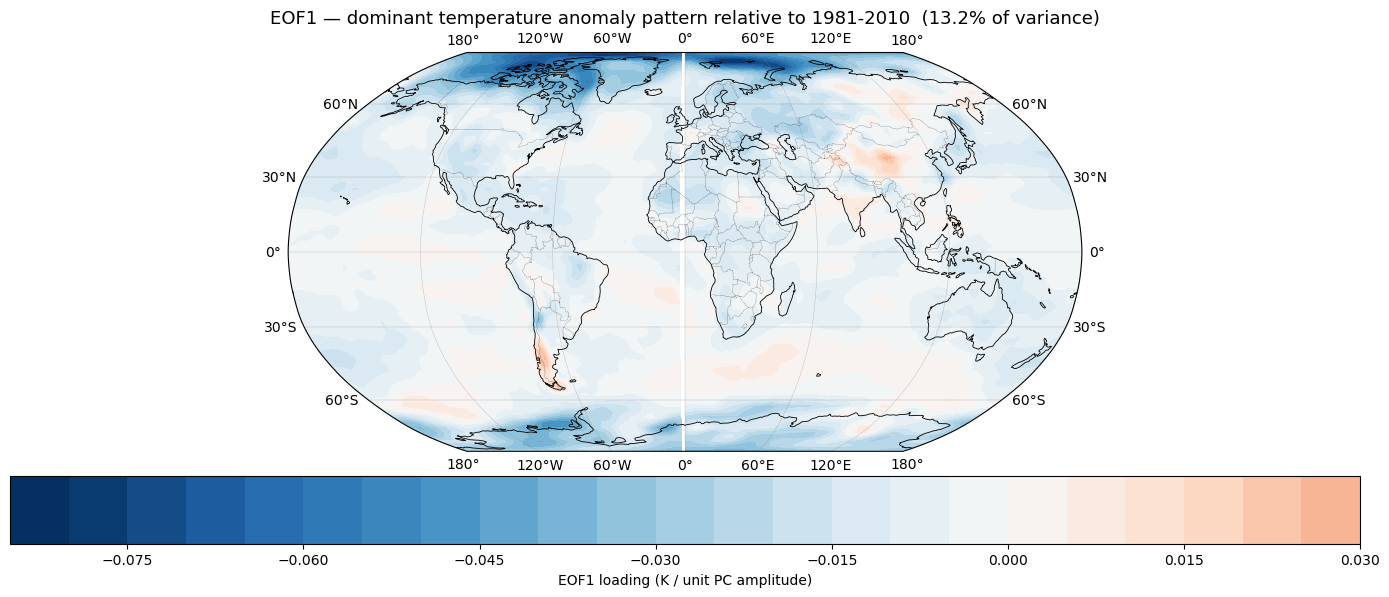

In [21]:
eof1 = np.where(w > 0, Vt[0, :] / np.where(w > 0, w, 1), np.nan).reshape(nlat, nlon)
var_frac1 = (S[0] ** 2) / np.sum(S**2)
print(f"EOF1 explains {var_frac1 * 100:.1f}% of total anomaly variance")

fig, ax = plt.subplots(figsize=(14, 6), subplot_kw={"projection": ccrs.Robinson()})

vmax = np.nanmax(
    np.abs(eof1)
)  # use nanmax to ignore NaN at poles (w=0 → divide by zero)
cf = ax.contourf(
    lons,
    lats,
    eof1,
    levels=21,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
plt.colorbar(
    cf,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    label="EOF1 loading (K / unit PC amplitude)",
)
ax.set_title(
    f"EOF1 — dominant temperature anomaly pattern relative to 1981-2010  ({var_frac1*100:.1f}% of variance)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 5. Mean anomaly map

To put EOF1 in context, it helps to also look at the **2025 annual mean anomaly** — the average temperature departure from the 1981-2010 climatology across all timesteps.

This is a different question from what EOF1 answers:

- **Mean anomaly map** — *Where* was 2025 warm or cool compared to the 1981-2010 baseline? This is a single snapshot summarizing the background state of the whole year.
- **EOF1 map** — *How* did temperatures fluctuate throughout 2025, and in what spatial pattern? This captures the dominant mode of variability on top of that background state.

Think of it this way: the mean anomaly map tells you the starting position; the EOF1 map tells you the direction in which things moved most often.

The two maps are complementary. The mean anomaly is expected to be almost entirely positive (red) because 2025 was globally much warmer than the 1981-2010 baseline. EOF1 then shows the spatial shape of the biggest fluctuations *around* that already-warm mean — which is why it appears mostly blue (negative loadings): the dominant fluctuation pattern is one where most of the world temporarily cools relative to the 2025 mean, while a few regions (e.g. parts of Central Asia, Patagonia) warm.

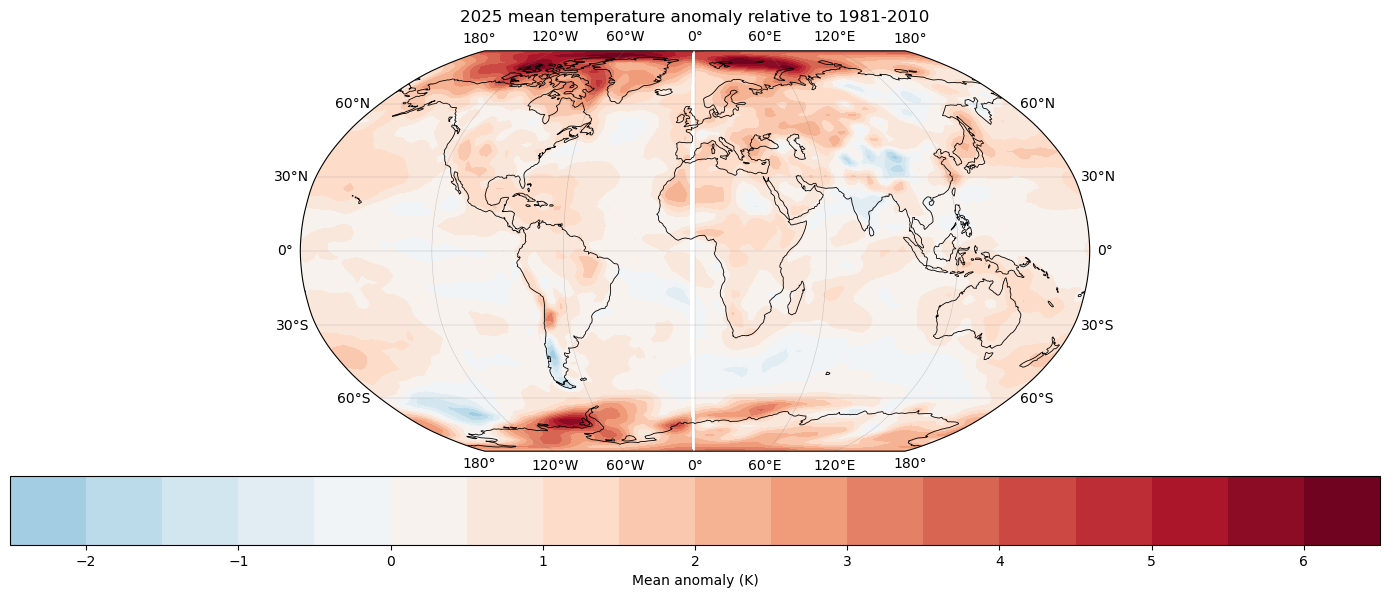

In [22]:
mean_anom = anomalies.mean(dim="time")

fig, ax = plt.subplots(figsize=(14, 6), subplot_kw={"projection": ccrs.Robinson()})
vmax = float(np.abs(mean_anom).max())
cf = ax.contourf(
    lons,
    lats,
    mean_anom.values,
    levels=21,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05, label="Mean anomaly (K)")
ax.set_title("2025 mean temperature anomaly relative to 1981-2010")
plt.tight_layout()
plt.show()